In [2]:
!pip install minisom
import matplotlib.pyplot as plt
from minisom import MiniSom
from keras.datasets import mnist

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for minisom: filename=minisom-2.3.6-py3-none-any.whl size=13182 sha256=da2ed937f9abd688f5e713fce76d8093223643b9025f5ffeff068997b8e19a7b
  Stored in directory: c:\users\admin\appdata\local\pip\cache\wheels\dc\11\f9\32be492f07fa741d7dcff82007abc966a324da6ab9ceb198e3
Successfully built minisom



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()
x_train = x_train.reshape(x_train.shape[0],-1) # minus one tells to finish dimensions and it will flatten image
x_train = x_train/255.0
x_train = x_train[:1000] # training k sirf pehly 1000
y_train = y_train[:1000]

In [4]:
som_width = 30
som_height = 30 # total 900 neurons on lettuce
input_len = x_train.shape[1] # x train is size of 1000 sample and total features are 784
som = MiniSom(som_width,som_height,input_len,
              sigma = 1.5,learning_rate = 0.5,# sigma is neighborhood radius
              neighborhood_function = 'triangle',activation_distance = 'euclidean',
              topology = 'rectangular', # 30 by 30 rectangular
              sigma_decay_function = 'linear_decay_to_one',
              decay_function='linear_decay_to_zero',
              random_seed = 349) # random seed controls randomness

som.pca_weights_init(x_train) # pca reduces dimensions
N_iterations = 1000
som.train_random(x_train,N_iterations,verbose = True)

c:\Python\Lib\site-packages\minisom.py:236: UserWarning: sigma should be an integer >=1 when triangle or bubbleare used as neighborhood function
  warn('sigma should be an integer >=1 when triangle or bubble' +


 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 4.2260909597483645


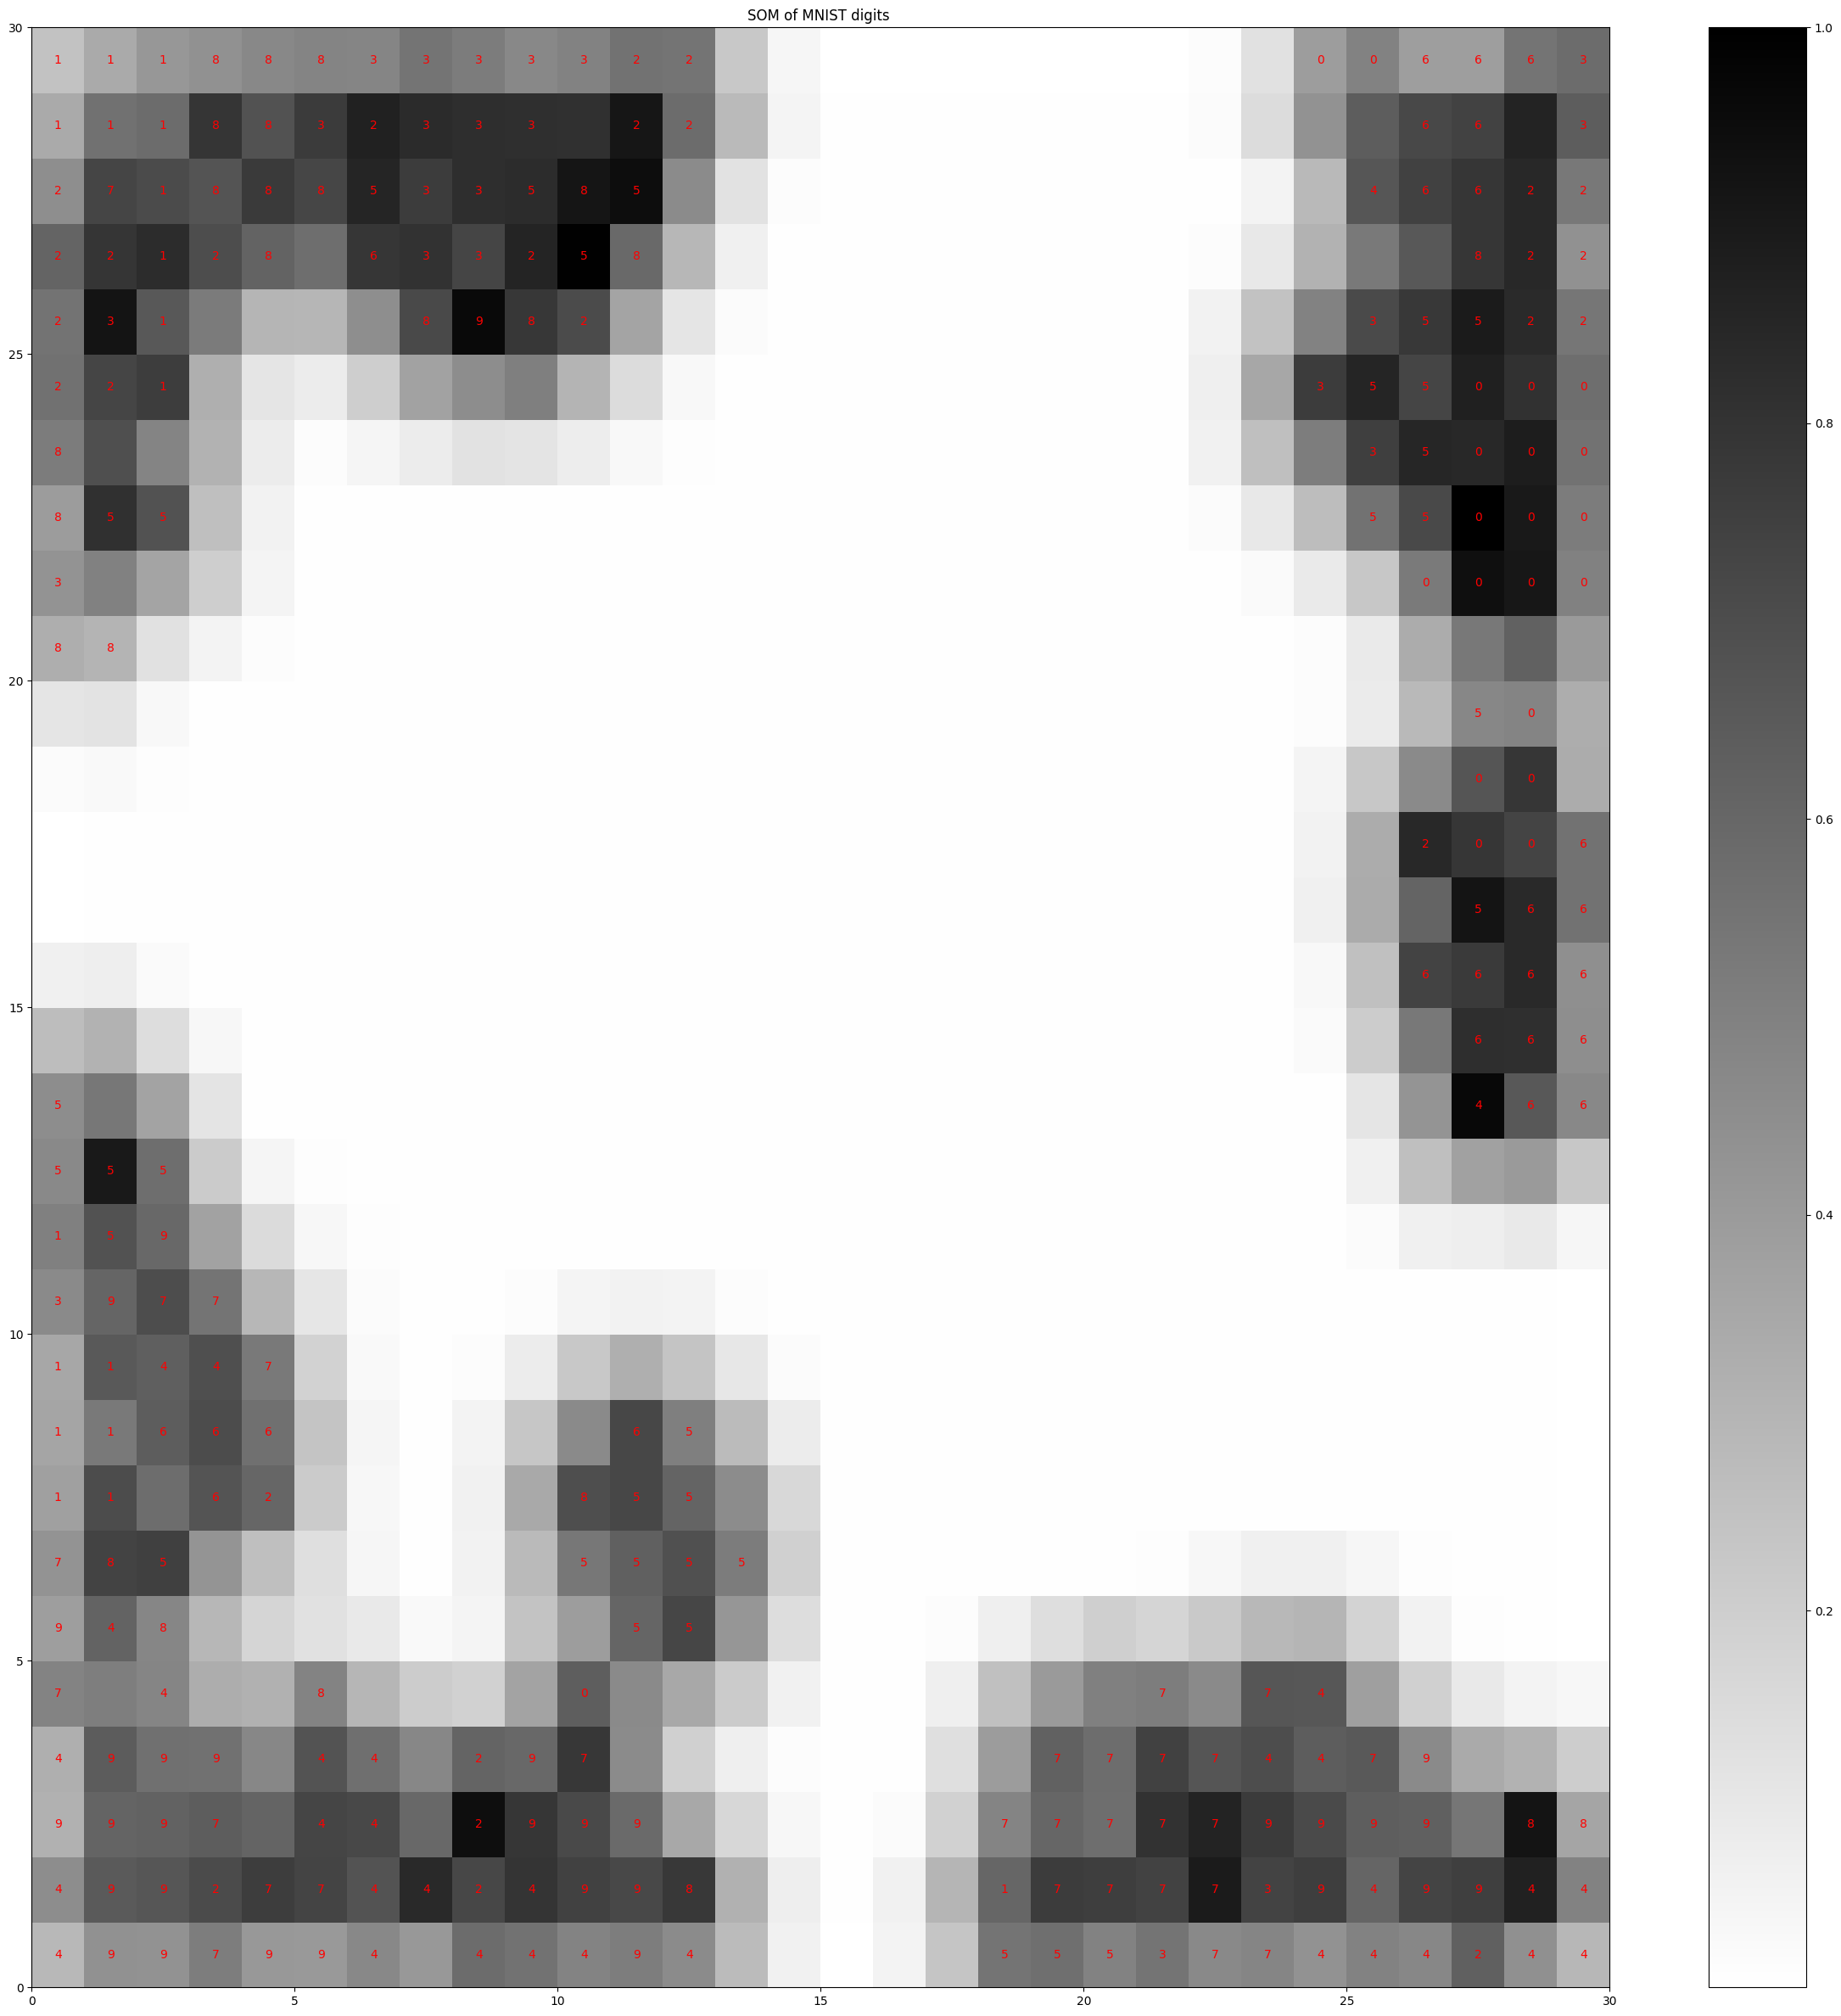

In [5]:
plt.figure(figsize = (som_width,som_height)) # or just type here 30 30
plt.pcolor(som.distance_map().T,cmap = 'gist_yarg')
plt.colorbar()
winner_count  = {}
for i,x in enumerate(x_train): # numerate picks sample of x train and returns indexes and sample
    winner = som.winner(x)
    if winner not in winner_count:
        winner_count[winner] = {}
    digit = y_train[i]
    winner_count[winner][digit] = winner_count[winner].get(digit,0)+1 # get will return key if there is digit we are returnring plus 1
for winner_coords,counts in winner_count.items(): # items picks keys and values
    most_frequent_digit = max(counts,key = counts.get)
    plt.text(winner_coords[0]+0.5,
             winner_coords[1]+0.5,
             str(most_frequent_digit),
             color = 'red',fontsize = 10,ha = 'center',
             va = 'center'
             ) # ha and va are showing text ki horizontal and verticle alignment
plt.title("SOM of MNIST digits ")
plt.show()

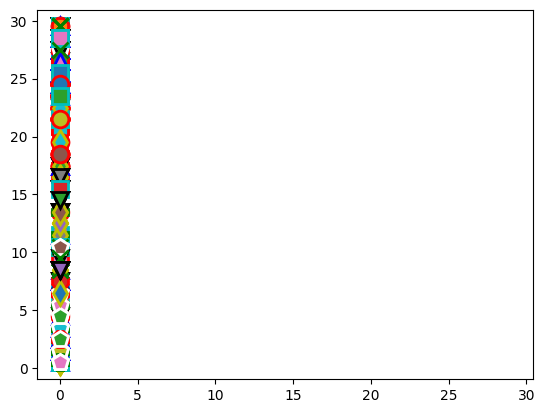

In [6]:
###########################################################################################
markers = ['o','x','^','s','y','d','v','p','8','P']
colors = ['r','g','b','c','m','y','k','w','r','g']
for count,datapoint in enumerate(x_train):
    w = som.winner(datapoint)
    plt.plot(w[0],+0.5,w[1]+0.5,
             markers[y_train[count]],
             markerfacecolor = None,
             markeredgecolor = colors[y_train[count]],
             markeredgewidth = 2,
             markersize = 12) # jo digit aae ga wo wala symbol uthae ga
plt.show()